# Setup API

In [1]:
!pip install "uvicorn[standard]" fastapi requests soundfile librosa scikit-learn scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.7/517.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 456.8/456.8 kB 17.8 MB/s eta 0:00:00


In [2]:
from google.colab import files
print("Upload mfcc_api.py, synthesize_api.py, dan (opsional) gmm_service.py jika ada.")
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))


Upload mfcc_api.py, synthesize_api.py, dan (opsional) gmm_service.py jika ada.


Saving gmm_service.py to gmm_service.py
Saving synthesize_api.py to synthesize_api.py
Saving mfcc_api.py to mfcc_api.py
Uploaded: ['gmm_service.py', 'synthesize_api.py', 'mfcc_api.py']


In [ ]:
import time, os, requests, io
from pprint import pprint
from pathlib import Path

# Port pilihan
MFCC_PORT = 8080
SYNTH_PORT = 8002
GMM_PORT = 8001   # nanti kalau mau jalankan GMM service juga

MFCC_API_URL = f"http://localhost:{MFCC_PORT}"
print("MFCC API URL:", MFCC_API_URL)
# # start MFCC API (assume module name mfcc_api.py with FastAPI app named `app`)
# print("Starting MFCC API on port", MFCC_PORT)
# os.system(f"nohup uvicorn mfcc_api:app --host 0.0.0.0 --port {MFCC_PORT} > mfcc_uvicorn.log 2>&1 &")
# time.sleep(1)

# # start synth API
# print("Starting Synthesize API on port", SYNTH_PORT)
# os.system(f"nohup uvicorn synthesize_api:app --host 0.0.0.0 --port {SYNTH_PORT} > synth_uvicorn.log 2>&1 &")
# time.sleep(1)

# print("Servers started (check mfcc_uvicorn.log and synth_uvicorn.log).")


Starting MFCC API on port 8000
Starting Synthesize API on port 8002
Servers started (check mfcc_uvicorn.log and synth_uvicorn.log).


In [4]:
# Jika ada file gmm_service.py di working dir
import os, time
if os.path.exists("gmm_service.py"):
    print("Starting GMM service on port", GMM_PORT)
    os.system(f"nohup uvicorn gmm_service:app --host 0.0.0.0 --port {GMM_PORT} > gmm_uvicorn.log 2>&1 &")
    time.sleep(1)
    print("GMM service started.")
else:
    print("gmm_service.py not found — skip starting GMM service.")


Starting GMM service on port 8001
GMM service started.


In [5]:
MFCC_API_URL = f"http://127.0.0.1:{MFCC_PORT}/extract_mfcc/"
SYNTH_URL    = f"http://127.0.0.1:{SYNTH_PORT}/synthesize/"
GMM_TRAIN_URL = f"http://127.0.0.1:{GMM_PORT}/train_model/"
GMM_SCORE_URL = f"http://127.0.0.1:{GMM_PORT}/score_file/"

print("MFCC_API_URL =", MFCC_API_URL)
print("SYNTH_URL    =", SYNTH_URL)
print("GMM_TRAIN_URL=", GMM_TRAIN_URL)


MFCC_API_URL = http://127.0.0.1:8000/extract_mfcc/
SYNTH_URL    = http://127.0.0.1:8002/synthesize/
GMM_TRAIN_URL= http://127.0.0.1:8001/train_model/


In [6]:
!tail -n 80 gmm_uvicorn.log


INFO:     Started server process [711]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8001 (Press CTRL+C to quit)


# Test API


In [7]:
# Colab test cell for new gmm_service
!pip install -q requests soundfile scipy matplotlib

GMM endpoints: http://127.0.0.1:8001/train_model/ http://127.0.0.1:8001/compare/ http://127.0.0.1:8001/plot_histogram/

Step 1: upload reference file(s) (choose 1..n .wav files)


Saving note_1_octave_5.wav to note_1_octave_5.wav
Saving saron_p1.wav to saron_p1.wav
Saving 1.wav to 1.wav
Saving 1_1.wav to 1_1.wav
Training model (uploading files)...
Train status: 200
{'model_name': 'saron_p1',
 'n_ref_frames': 2921,
 'q10': -16.42061420279144,
 'q90': -1.5243410086296076,
 'threshold': -21.23712598819661,
 'train_mean': -9.145999941864613,
 'train_std': 6.045563023165998}

Step 2: upload test file


Saving 1.wav to 1 (1).wav
Calling compare...
Compare status: 200
{'avg_mean': -8.37731602825376,
 'avg_median': -8.135397221789733,
 'avg_topk': 1.3267781957479245,
 'is_match_mean': True,
 'is_match_topk': True,
 'n_frames': 694,
 'percent_similarity_mean': 55.05885439242489,
 'percent_similarity_topk': 95.83906447784113,
 'test_file': '1 (1).wav',
 'threshold': -21.23712598819661,
 'train_mean': -9.145999941864613,
 'train_std': 6.045563023165998,
 'z_score_mean': 0.12714844104102985,
 'z_score_topk': 1.7323081568221008}

Local recomputed percent_normcdf_mean (from avg_mean): 55.05885439242489

Requesting histogram (train vs test) ...


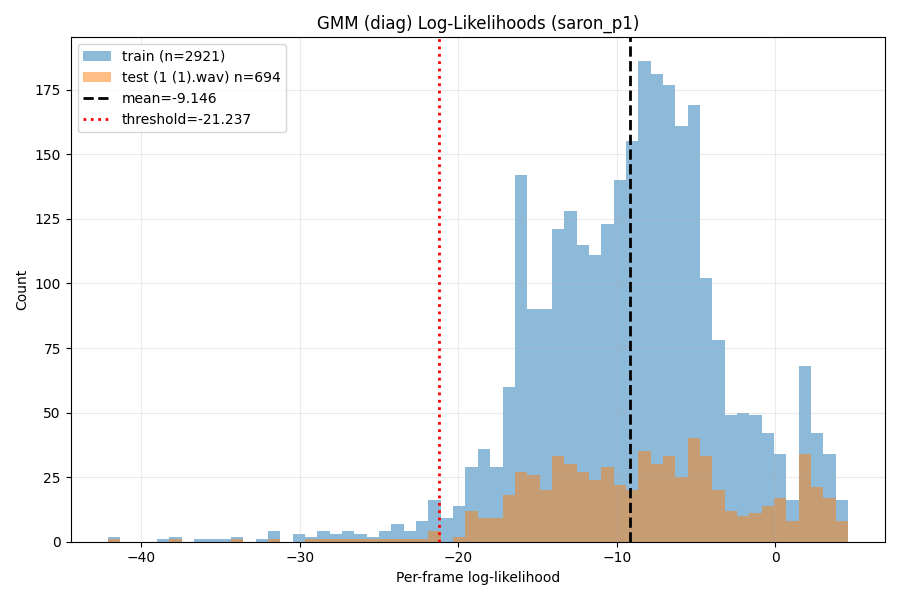

Saved gmm_hist.png

Done.


In [8]:
from google.colab import files
import requests, io, time
import numpy as np
from pprint import pprint
from IPython.display import Image, display

GMM_BASE = "http://127.0.0.1:8001"
TRAIN_URL = f"{GMM_BASE}/train_model/"
COMPARE_URL = f"{GMM_BASE}/compare/"
PLOT_URL = f"{GMM_BASE}/plot_histogram/"

print("GMM endpoints:", TRAIN_URL, COMPARE_URL, PLOT_URL)

# 1) upload reference(s)
print("\nStep 1: upload reference file(s) (choose 1..n .wav files)")
refs = files.upload()
if not refs:
    raise SystemExit("No reference files uploaded")

files_payload = [('files', (name, io.BytesIO(content), 'audio/wav')) for name, content in refs.items()]
data = {'model_name': 'saron_p1', 'n_components': 8}
print("Training model (uploading files)...")
r = requests.post(TRAIN_URL, files=files_payload, data=data, timeout=180)
print("Train status:", r.status_code)
try:
    train_j = r.json()
    pprint(train_j)
except Exception:
    print("Train response:", r.text[:400])
    raise

# 2) upload test file
print("\nStep 2: upload test file")
t = files.upload()
if not t:
    raise SystemExit("No test file uploaded")
test_name = list(t.keys())[0]
test_bytes = t[test_name]

files_for_compare = {'test_file': (test_name, io.BytesIO(test_bytes), 'audio/wav')}
payload = {'reference_model': data['model_name'], 'pooling_mode': 'topk', 'topk': 0.2}
print("Calling compare...")
rc = requests.post(COMPARE_URL, files=files_for_compare, data=payload, timeout=120)
print("Compare status:", rc.status_code)
res = rc.json()
pprint(res)

# 3) Show local norm.cdf percent (validate)
if all(k in res for k in ('avg_mean','train_mean','train_std')):
    avg_mean = float(res['avg_mean'])
    train_mean = float(res['train_mean'])
    train_std = float(res['train_std']) if float(res['train_std'])!=0 else 1.0
    z = (avg_mean - train_mean) / train_std
    from scipy.stats import norm
    pct_norm_local = float(norm.cdf(z) * 100.0)
    print("\nLocal recomputed percent_normcdf_mean (from avg_mean):", pct_norm_local)

# 4) request histogram plot
print("\nRequesting histogram (train vs test) ...")
files_for_plot = {'test_file': (test_name, io.BytesIO(test_bytes), 'audio/wav')}
plot_payload = {'reference_model': data['model_name']}
pr = requests.post(PLOT_URL, files=files_for_plot, data=plot_payload, timeout=120)
if pr.status_code == 200 and pr.headers.get('content-type','').startswith('image'):
    open("gmm_hist.png","wb").write(pr.content)
    display(Image("gmm_hist.png"))
    print("Saved gmm_hist.png")
else:
    print("Plot failed:", pr.status_code)
    print(pr.text[:400])

print("\nDone.")